In [64]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


# **Exploratory Data Analysis (EDA)**

# **Project Title**

**Exploratory Data Analysis on Netflix Movies and TV Shows Dataset**

# 1. Objective
The objective of this project is to analyze the Netflix Movies and TV Shows dataset and extract meaningful insights using Exploratory Data Analysis (EDA). The analysis helps in understanding trends, content distribution, ratings, release patterns, and country-wise production.

# 2. Tools & Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter
* Notebook


# 3. Dataset

Dataset Name: Netflix Movies and TV Shows

Dataset Source: https://www.kaggle.com/datasets/shivamb/netflix-shows

# 4. Import Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Load Dataset 

In [66]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

# 6. Basic Dataset Information

In [67]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

# 7. Data Cleaning

**Check Missing Values**

In [68]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


**Fill Missing Values**

In [69]:
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df = df.drop_duplicates()

**Remove Duplicates**

In [70]:
df.drop_duplicates(inplace=True)

# 8. Exploratory Data Analysis

**Question 1: Number of Movies vs TV Shows**

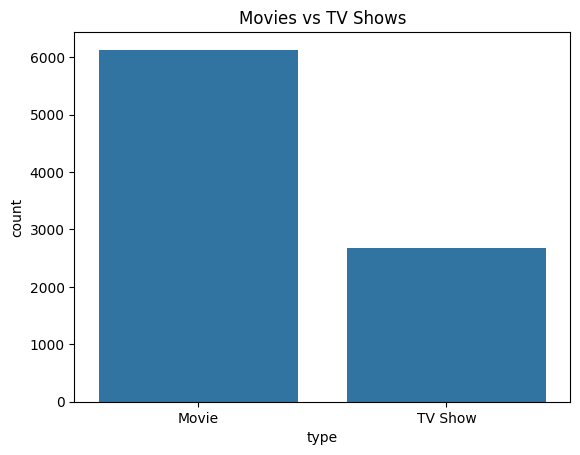

In [71]:
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

**Observation**

Netflix contains more movies than TV shows.

**Question 2: Top 10 Countries Producing Content**

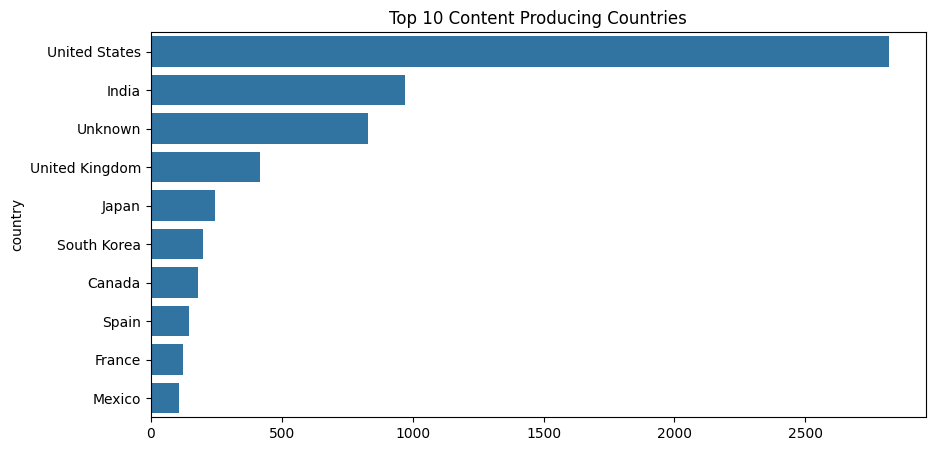

In [72]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Content Producing Countries')
plt.show()

**Observation**

The United States contributes the highest amount of content.

**Question 3: Content Added Over the Years**

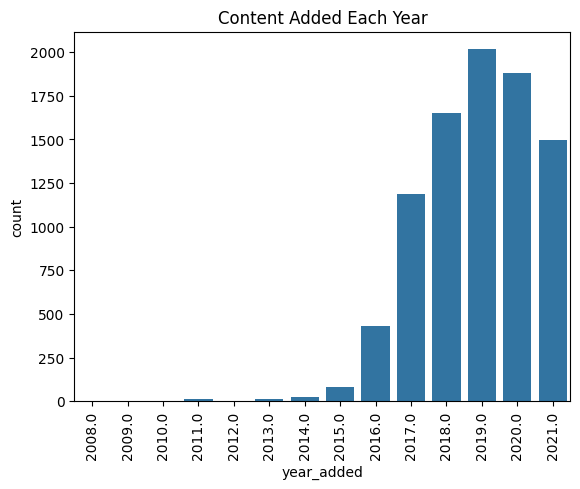

In [73]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

sns.countplot(x='year_added', data=df)
plt.xticks(rotation=90)
plt.title('Content Added Each Year')
plt.show()

**Observation**

Netflix content increased rapidly after 2015.

**Question 4: Most Common Ratings**

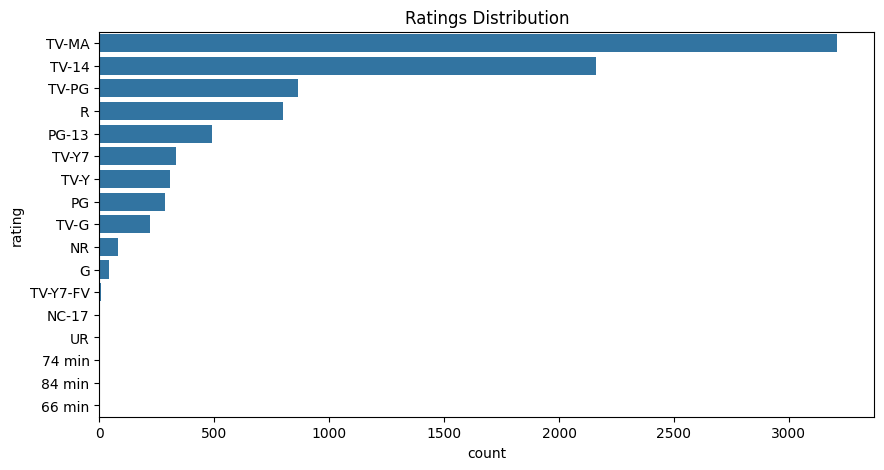

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Ratings Distribution')
plt.show()

**Observation**

TV-MA and TV-14 are the most common ratings.

**Question 5: Movie Duration Analysis**

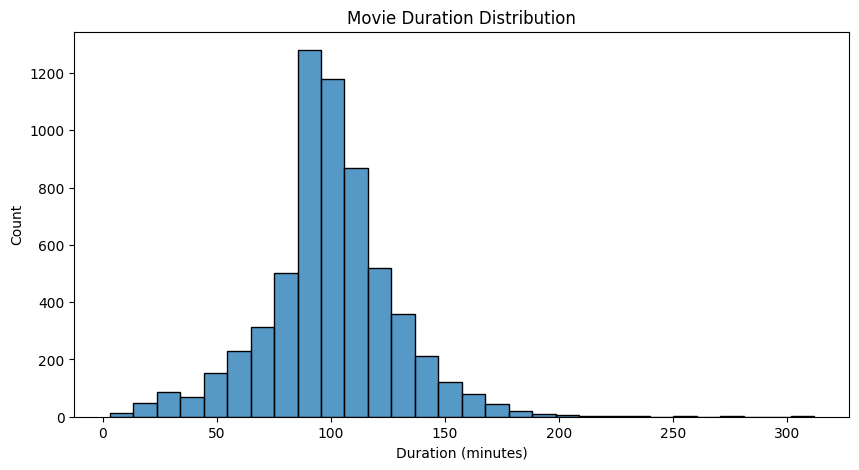

In [75]:
movies = df[df['type'] == 'Movie'].copy()

# Drop NaN durations first, then convert
movies = movies.dropna(subset=['duration'])
movies['duration_int'] = movies['duration'].str.replace(' min', '', regex=False).str.strip().astype(int)

plt.figure(figsize=(10,5))
sns.histplot(movies['duration_int'], bins=30)
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.show()

**Observation**

Most movies have durations between 80 and 120 minutes.

# 9. Key Insights
1. Movies dominate the Netflix platform.
2. The USA is the leading producer of Netflix content.
3. Content growth increased significantly after 2015.
4. Mature audience content is most common.
5. Average movie duration ranges from 80–120 minutes.

# 10. Conclusion

This EDA project successfully analyzed Netflix content trends and identified patterns related to content type, ratings, production countries, and duration. The project demonstrates how data analysis techniques help organizations make data-driven decisions.